# **1. DATA EXPLORE**

## **1.1. Kiểu dữ liệu**

In [1]:
import pandas as pd
import re
import unicodedata
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data.csv")
df.head()

# Lấy kiểu dữ liệu
df.dtypes
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19817 entries, 0 to 19816
Data columns (total 29 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   product_id                    19817 non-null  int64  
 1   product_name                  19817 non-null  object 
 2   product_url                   19817 non-null  object 
 3   category_id                   19817 non-null  int64  
 4   category_name                 19817 non-null  object 
 5   category_root_name            19817 non-null  object 
 6   price                         19811 non-null  float64
 7   original_price                19811 non-null  float64
 8   discount_rate                 19811 non-null  float64
 9   quantity_sold                 14172 non-null  float64
 10  rating_average                19811 non-null  float64
 11  review_count                  19811 non-null  float64
 12  is_return_policy              19811 non-null  float64
 13  i

## **1.2. Khám phá Missing Value dạng text**

In [2]:
# In những cột missing value và tỷ lệ missing value

# Các cột text
text_cols = [
    'product_id',
    'product_name',
    'product_url',
    'category_id',
    'category_name',
    'category_root_name',
    'brand_name',
    'origin',
    'store_id',
    'store_name',
    'cancel_by_seller_rate_status',
    'return_rate_status'
    ]


# Dictionary để lưu cột và số dòng bị thiếu ở cột đó
missing_dict = {}

count = 0
for col in text_cols:
    number_missing_value = df[col].isnull().sum()
    if(number_missing_value>0): 
        count+=1
    missing_dict.update({col:number_missing_value})

print(f"{'Cột':30} {'Số lượng':10} {'Phần trăm':10}")
print("-" * 55)

for col, val in missing_dict.items():
    percent = round(val / len(df) * 100, 3)
    print(f"{col:30} {val:<10} {percent:<10}%")

print("\nSố cột chứa missing value: ", count)


Cột                            Số lượng   Phần trăm 
-------------------------------------------------------
product_id                     0          0.0       %
product_name                   0          0.0       %
product_url                    0          0.0       %
category_id                    0          0.0       %
category_name                  0          0.0       %
category_root_name             0          0.0       %
brand_name                     247        1.246     %
origin                         1002       5.056     %
store_id                       120        0.606     %
store_name                     208        1.05      %
cancel_by_seller_rate_status   120        0.606     %
return_rate_status             120        0.606     %

Số cột chứa missing value:  6


## **1.3. Khám phá Missing Value dạng numberic**

File được tìm thấy tại: data.csv
Đã đọc thành công file với 19817 dòng và 29 cột

Đã lưu file đã xử lý tại: data_processed.csv

PHÂN TÍCH MISSING VALUES TRÊN DỮ LIỆU ĐÃ XỬ LÝ

BẢNG TỈ LỆ MISSING VALUES:
           Thuộc tính  Số lượng missing  Tỉ lệ missing (%)
                price                 6               0.03
       original_price                 6               0.03
        discount_rate                 6               0.03
        quantity_sold              5645              28.49
       rating_average                 6               0.03
         review_count                 6               0.03
     is_return_policy                 6               0.03
     is_freeship_xtra                69               0.35
         is_authentic                69               0.35
          image_count                 6               0.03
          video_count                 6               0.03
             is_brand                 6               0.03
   store_review_count         

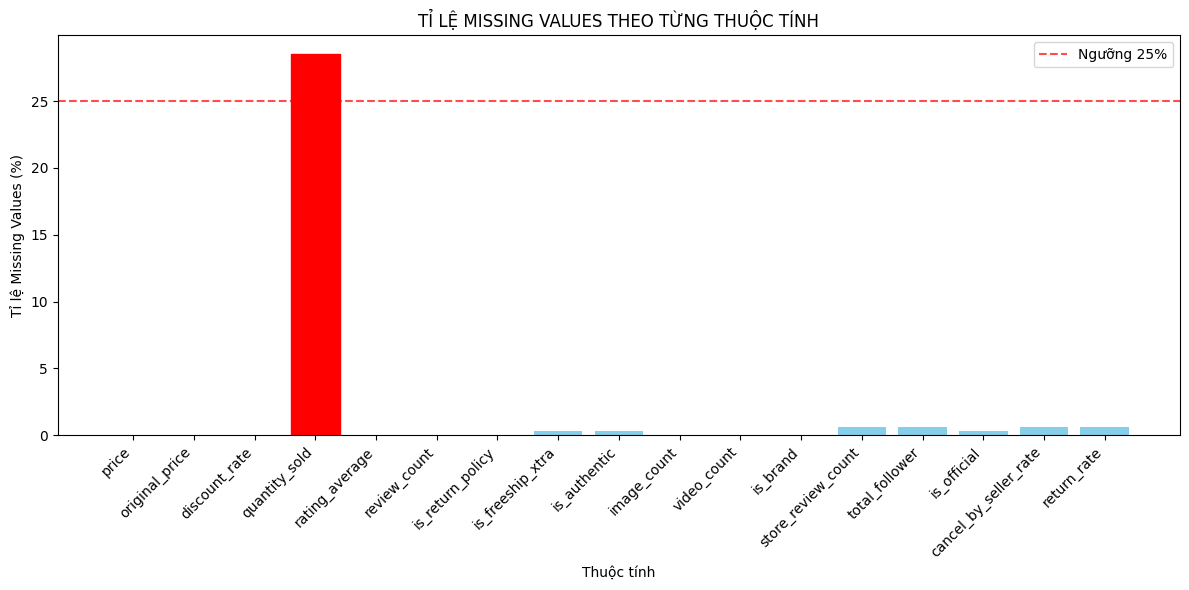


THÔNG TIN CHI TIẾT VỀ PHÂN BỐ CỦA TẤT CẢ CÁC CỘT (BẢNG TỔNG HỢP):
           Thuộc tính Kiểu dữ liệu  Số giá trị unique  Số lượng missing  Tỉ lệ missing (%)    Min          Max         Mean   Median          Std          Var  Q1 (25%)  Q3 (75%)
                price      float64               4003                 6               0.03 1000.0 1303175000.0 2.141108e+06 230000.0 1.795736e+07 3.224667e+14  102000.0  591500.0
       original_price      float64               3248                 6               0.03 1000.0 1303175000.0 2.286530e+06 259000.0 1.811222e+07 3.280524e+14  118000.0  660000.0
        discount_rate      float64                 79                 6               0.03    0.0         83.0 9.086921e+00      0.0 1.410814e+01 1.990395e+02       0.0      20.0
        quantity_sold      float64               1670              5645              28.49    0.0     671583.0 7.483551e+02     16.0 8.758515e+03 7.671159e+07       3.0      91.0
       rating_average      float64    

In [3]:
#!pip install matplotlib
import pandas as pd
import numpy as np
import os

file_path = 'data.csv' 

# Kiểm tra xem file có tồn tại không
if not os.path.exists(file_path):
    # Tìm kiếm file trong toàn bộ thư mục hiện tại
    import glob
    search_results = glob.glob('**/data.csv', recursive=True)

    if search_results:
        file_path = search_results[0]
        print(f"Tìm thấy file tại: {file_path}")
    else:
        print("Không tìm thấy file data.csv trong thư mục hiện tại. Vui lòng kiểm tra đường dẫn.")
        # Tạo danh sách các file CSV có sẵn
        csv_files = glob.glob('**/*.csv', recursive=True)
        if csv_files:
            print("\nCác file CSV có sẵn trong thư mục hiện tại:")
            for i, file in enumerate(csv_files[:10], 1):
                print(f"{i}. {file}")
else:
    print(f"File được tìm thấy tại: {file_path}")

# Đọc dữ liệu
try:
    df = pd.read_csv(file_path)
    print(f"Đã đọc thành công file với {len(df)} dòng và {len(df.columns)} cột")
except Exception as e:
    print(f"Lỗi khi đọc file: {e}")
    # Thử đọc với encoding khác nếu cần
    try:
        df = pd.read_csv(file_path, encoding='utf-8')
    except:
        try:
            df = pd.read_csv(file_path, encoding='latin-1')
        except:
            print("Không thể đọc file với các encoding thông thường.")

# Xử lý chuyển đổi dữ liệu phần trăm

# Tạo bản sao để xử lý
df_processed = df.copy()

# Xử lý cột 'cancel_by_seller_rate' và 'return_rate'
percent_columns = ['cancel_by_seller_rate', 'return_rate']

for col in percent_columns:
    if col in df_processed.columns:
        # Đếm số lượng giá trị không phải NaN
        non_null_count = df_processed[col].notna().sum()

        if non_null_count > 0:

            # Kiểm tra xem có chứa ký tự '%' không
            has_percent = df_processed[col].astype(str).str.contains('%').any()

            # Xử lý chuyển đổi
            if has_percent:
                # Loại bỏ ký tự '%' và chuyển đổi sang số
                df_processed[col] = df_processed[col].astype(str).str.replace('%', '', regex=False)

                # Loại bỏ khoảng trắng
                df_processed[col] = df_processed[col].str.strip()

                # Chuyển đổi sang số, không hợp lệ sẽ thành NaN
                df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')

                # Chia cho 100 để chuyển từ phần trăm sang số thập phân
                df_processed[col] = df_processed[col] / 100
            else:
                # Nếu không có '%', thử chuyển trực tiếp sang số
                df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
    else:
        print(f"\nCột '{col}' không tồn tại trong dataset")

# Danh sách các cột số cần kiểm tra
numeric_columns_to_check = [
    'price', 'original_price', 'discount_rate', 'quantity_sold',
    'rating_average', 'review_count', 'is_return_policy',
    'is_freeship_xtra', 'is_authentic', 'image_count', 'video_count',
    'is_brand', 'store_review_count', 'total_follower', 'is_official'
]

for col in numeric_columns_to_check:
    if col in df_processed.columns:
        if df_processed[col].dtype == 'object':
            print(f"\nCột '{col}' có kiểu object, đang chuyển sang numeric...")

            # Đếm số giá trị không phải NaN trước khi chuyển
            before_count = df_processed[col].notna().sum()

            # Chuyển đổi sang numeric
            df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')

            # Đếm số giá trị không phải NaN sau khi chuyển
            after_count = df_processed[col].notna().sum()

            lost_values = before_count - after_count
            if lost_values > 0:
                print(f"  - Mất {lost_values} giá trị không thể chuyển đổi")

            print(f"  - Kiểu dữ liệu sau: {df_processed[col].dtype}")

# Lưu file CSV mới
output_file_path = 'data_processed.csv'
df_processed.to_csv(output_file_path, index=False)
print(f"\nĐã lưu file đã xử lý tại: {output_file_path}")

# Phân tích missing values trên dữ liệu đã xử lý
print("\n" + "="*60)
print("PHÂN TÍCH MISSING VALUES TRÊN DỮ LIỆU ĐÃ XỬ LÝ")
print("="*60)

# Sử dụng dataframe đã xử lý
df = df_processed

# Danh sách các cột cần kiểm tra
columns_to_check = [
    'price', 'original_price', 'discount_rate', 'quantity_sold',
    'rating_average', 'review_count', 'is_return_policy',
    'is_freeship_xtra', 'is_authentic', 'image_count', 'video_count',
    'is_brand', 'store_review_count', 'total_follower', 'is_official',
    'cancel_by_seller_rate', 'return_rate'
]

# Kiểm tra xem các cột có tồn tại trong dataframe không
existing_columns = [col for col in columns_to_check if col in df.columns]
missing_columns = [col for col in columns_to_check if col not in df.columns]

if missing_columns:
    print(f"Các cột không tồn tại trong dataset: {missing_columns}")
    print(f"Tiếp tục với {len(existing_columns)} cột có sẵn...")


# Tính missing values
total_rows = len(df)

missing_data = []
for col in existing_columns:
    missing_count = df[col].isnull().sum()
    missing_percent = (missing_count / total_rows) * 100

    missing_data.append({
        'Thuộc tính': col,
        'Số lượng missing': missing_count,
        'Tỉ lệ missing (%)': round(missing_percent, 2)
    })

# Tạo dataframe missing_df
missing_df = pd.DataFrame(missing_data)

print("\nBẢNG TỈ LỆ MISSING VALUES:")
print(missing_df.to_string(index=False))


# Trực quan hóa kết quả
import matplotlib.pyplot as plt

# Tạo biểu đồ tỉ lệ missing values
plt.figure(figsize=(12, 6))
bars = plt.bar(missing_df['Thuộc tính'], missing_df['Tỉ lệ missing (%)'], color='skyblue')
plt.axhline(y=25, color='r', linestyle='--', alpha=0.7, label='Ngưỡng 25%')
plt.xlabel('Thuộc tính')
plt.ylabel('Tỉ lệ Missing Values (%)')
plt.title('TỈ LỆ MISSING VALUES THEO TỪNG THUỘC TÍNH')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()

# Tô màu đỏ cho các cột có missing > 25%
for i, (bar, rate) in enumerate(zip(bars, missing_df['Tỉ lệ missing (%)'])):
    if rate > 25:
        bar.set_color('red')

plt.show()

# Hiển thị thông tin chi tiết về phân bố của TẤT CẢ các cột dưới dạng BẢNG
print("\nTHÔNG TIN CHI TIẾT VỀ PHÂN BỐ CỦA TẤT CẢ CÁC CỘT (BẢNG TỔNG HỢP):")
print("=" * 80)

summary_stats = []

for col in existing_columns:
    col_data = df[col]
    dtype = col_data.dtype
    n_unique = col_data.nunique()
    missing_count = col_data.isnull().sum()
    missing_percentage = (missing_count / total_rows) * 100

    # Giá trị mặc định cho các thống kê số
    min_val = max_val = mean_val = median_val = std_val = var_val = q25 = q75 = np.nan

    if pd.api.types.is_numeric_dtype(col_data):
        numeric_data = col_data.dropna()
        if len(numeric_data) > 0:
            min_val = numeric_data.min()
            max_val = numeric_data.max()
            mean_val = numeric_data.mean()
            median_val = numeric_data.median()
            std_val = numeric_data.std()
            var_val = numeric_data.var()
            q25 = numeric_data.quantile(0.25)
            q75 = numeric_data.quantile(0.75)

    summary_stats.append({
        'Thuộc tính': col,
        'Kiểu dữ liệu': dtype,
        'Số giá trị unique': n_unique,
        'Số lượng missing': missing_count,
        'Tỉ lệ missing (%)': round(missing_percentage, 2),
        'Min': min_val,
        'Max': max_val,
        'Mean': mean_val,
        'Median': median_val,
        'Std': std_val,
        'Var': var_val,
        'Q1 (25%)': q25,
        'Q3 (75%)': q75
    })

summary_df = pd.DataFrame(summary_stats)

# Sắp xếp cột cho đẹp (có thể chỉnh lại thứ tự nếu muốn)
cols_order = [
    'Thuộc tính', 'Kiểu dữ liệu', 'Số giá trị unique',
    'Số lượng missing', 'Tỉ lệ missing (%)',
    'Min', 'Max', 'Mean', 'Median', 'Std', 'Var',
    'Q1 (25%)', 'Q3 (75%)'
]
summary_df = summary_df[cols_order]

# In bảng thống kê
print(summary_df.to_string(index=False))
print("=" * 80)






## **1.4. Thống kê trùng lặp**

In [4]:
# Kiểm tra để đảm bảo không có giá trị trùng lặp hoặc không hợp lệ
product_cols = ['product_id', 'product_url']

for col in product_cols:
    duplicates = df[col][df[col].duplicated()]
    if not duplicates.empty:
        print(f"Có giá trị trùng trong cột '{col}':")
        print(duplicates.unique())
    else:
        print(f"Không có giá trị trùng trong cột '{col}':")

Không có giá trị trùng trong cột 'product_id':
Không có giá trị trùng trong cột 'product_url':


## **1.5. Khám phá Outliers**

In [5]:
#!pip install seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. ĐỌC DỮ LIỆU
df = pd.read_csv('data.csv')
print(f"Đã đọc dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột\n")

# 2. DANH SÁCH CÁC CỘT CẦN PHÂN TÍCH
columns_for_boxplot = [
    'price', 'original_price', 'discount_rate', 'quantity_sold',
    'rating_average', 'review_count', 'image_count', 'video_count',
    'store_review_count', 'total_follower', 
    'cancel_by_seller_rate', 'return_rate'
]

# 3. TÍNH TOÁN THÔNG SỐ OUTLIERS
print("="*80)
print("PHÂN TÍCH OUTLIERS THEO PHƯƠNG PHÁP IQR")
print("="*80)

results = []
for col in columns_for_boxplot:
    if col in df.columns:
        data = df[col]
        
        # Tính IQR và bounds
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Xác định outliers
        outliers = data[(data < lower_bound) | (data > upper_bound)]
        
        # Tính skewness (độ lệch)
        median = data.median()
        mean = data.mean()
        
            # Nhận xét về phân phối
        if median < mean:
            skewness_note = "Lệch phải (right-skewed)"
        elif median > mean:
            skewness_note = "Lệch trái (left-skewed)"
        else:
            skewness_note = "Cân bằng"
        # Lưu kết quả
        results.append({
            'Cột': col,
            'IQR': round(IQR, 2),
            'Lower Bound': round(lower_bound, 2),
            'Upper Bound': round(upper_bound, 2),
            'Số outliers': len(outliers),
            'Tỉ lệ outliers': f"{len(outliers)/len(data)*100:.1f}%",
            'Min outlier': round(outliers.min(), 2) if len(outliers) > 0 else "Không có",
            'Max outlier': round(outliers.max(), 2) if len(outliers) > 0 else "Không có",
            'Phân phối': skewness_note
        })

# 4. IN BẢNG KẾT QUẢ
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# 5. VẼ BOX PLOT
print("\n" + "="*80)
print("VẼ BOX PLOT")
print("="*80)

# Tạo figure lớn với nhiều subplot
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(columns_for_boxplot):
    if i < len(axes):
        ax = axes[i]
        
        # Vẽ box plot
        boxplot = ax.boxplot(df[col].dropna(), patch_artist=True)
        
        # Tùy chỉnh màu sắc 
        boxplot['boxes'][0].set_facecolor('lightblue')
        boxplot['medians'][0].set_color('red')
        
        # Thêm thông tin
        median_val = df[col].median()
        outliers_count = results[i]['Số outliers']
        
        # Đặt tiêu đề với thông tin phân phối
        color = 'red' if 'Lệch phải' in results[i]['Phân phối'] else 'blue' if 'Lệch trái' in results[i]['Phân phối'] else 'green'
        ax.set_title(f"{col}\n({results[i]['Phân phối']})", 
                    fontsize=12, fontweight='bold', color=color)
        ax.set_ylabel('Giá trị')
        ax.grid(True, alpha=0.3)
        
        # Hiển thị số outliers
        ax.text(0.95, 0.95, f'Outliers: {outliers_count}', 
                transform=ax.transAxes, fontsize=10,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

# Ẩn các subplot không sử dụng
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('BOX PLOT - PHÂN TÍCH OUTLIERS VÀ PHÂN PHỐI', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



Đã đọc dữ liệu: 19817 dòng, 29 cột

PHÂN TÍCH OUTLIERS THEO PHƯƠNG PHÁP IQR


TypeError: unsupported operand type(s) for -: 'str' and 'str'

## **1.6. Data Reduction sơ bộ**

### **1.6.1. Numberic**

### **1.6.2. Text**

## **1.7. Initial Preprocessing**

## **1.8. EDA**

# **2. DATA PREPROCESSING**

## **2.1. Data Cleaning**

### **2.1.1. Xử lý Missing Value dạng text**

In [6]:
# Đối với brand_name và origin điền "Unknown"
print("Số lượng missing value trước khi điền: ")
for col in ['brand_name','origin']:
    print(f"{col}: {missing_dict[col]}")
    df[col] = df[col].fillna('Unknown')

# Kiểm tra và cập nhật missing_dict
print("Số lượng missing value sau khi điền: ")
for col in ['brand_name','origin']:
    number_missing_value = df[col].isna().sum()
    missing_dict[col] = number_missing_value
    
    print(f"{col}: {missing_dict[col]}")    
    
    
# Đối với store_id, giá trị thiếu điền 0
print("Số lượng missing value trước khi điền: ")
for col in ['store_id']:
    print(f"{col}: {missing_dict[col]}")
    df[col] = df[col].fillna(0)

# Kiểm tra và cập nhật missing_dict
print("Số lượng missing value sau khi điền: ")
for col in ['store_id']:
    number_missing_value = df[col].isna().sum()
    missing_dict[col] = number_missing_value
    
    print(f"{col}: {missing_dict[col]}")    
    
    
    

    
# Đối với store_name, lấy store_id và đối chiếu với các hàng khác để tìm store_name
# Nếu không có thì điền "Unknown"

print("Số lượng missing value trước khi điền: ")
for col in ['store_name']:
    print(f"{col}: {missing_dict[col]}")
    
# Tạo dictionary mapping store_id -> store_name
store_map = df.dropna(subset=['store_name']).drop_duplicates('store_id')
store_map = store_map.set_index('store_id')['store_name'].to_dict()

def fill_store_name(row):
    if pd.isna(row['store_name']):
        return store_map.get(row['store_id'], "Unknown")
    return row['store_name']

df['store_name'] = df.apply(fill_store_name, axis =1)

# Thống kê số lượng "Unknown"
unknown_count = (df['store_name'] == "Unknown").sum()
unknown_percent = round(unknown_count / missing_dict['store_name'] * 100, 3)
print(f"\nTỷ lệ Unknown trong {missing_dict['store_name']} giá trị missing value:", unknown_percent, "%")

# Kiểm tra và cập nhật missing_dict
print("\nSố lượng missing value sau khi điền: ")
for col in ['store_name']:
    number_missing_value = df[col].isna().sum()
    missing_dict[col] = number_missing_value
    
    print(f"{col}: {missing_dict[col]}")      
    


# Đối với cancel_by_seller_rate_status nếu cancel_by_seller_rate tồn tại thì điền mode
# Nếu không tồn tại thì điền Unknown
print("Số lượng missing value trước khi điền: ")
for col in ['cancel_by_seller_rate_status']:
    print(f"{col}: {missing_dict[col]}")

# Lấy giá trị mode
mode_status = df['cancel_by_seller_rate_status'].mode()
# Lấy giá trị mode đầu tiên
if len(mode_status) > 0:
    mode_status = mode_status.iloc[0]
else:
    mode_status = "Unknown"

# Điền giá trị
df['cancel_by_seller_rate_status'] = df.apply(
    lambda row: mode_status if pd.notnull(row['cancel_by_seller_rate']) and pd.isnull(row['cancel_by_seller_rate_status'])
                else ("Unknown" if pd.isnull(row['cancel_by_seller_rate']) and pd.isnull(row['cancel_by_seller_rate_status'])
                      else row['cancel_by_seller_rate_status']),
    axis=1
)
# Kiểm tra và cập nhật missing_dict
print("Số lượng missing value sau khi điền: ")
for col in ['cancel_by_seller_rate_status']:
    number_missing_value = df[col].isna().sum()
    missing_dict[col] = number_missing_value
    
    print(f"{col}: {missing_dict[col]}")  

    
    



# Đối với return_rate_status nếu return_rate tồn tại thì điền mode
# Nếu không tồn tại thì điền Unknown
 
print("Số lượng missing value trước khi điền: ")
for col in ['return_rate_status']:
    print(f"{col}: {missing_dict[col]}")

# Lấy giá trị mode
mode_status = df['return_rate_status'].mode()
# Lấy giá trị mode đầu tiên
if len(mode_status) > 0:
    mode_status = mode_status.iloc[0]
else:
    mode_status = "Unknown"

# Điền giá trị
df['return_rate_status'] = df.apply(
    lambda row: mode_status if pd.notnull(row['return_rate']) and pd.isnull(row['return_rate_status'])
                else ("Unknown" if pd.isnull(row['return_rate']) and pd.isnull(row['return_rate_status'])
                      else row['return_rate_status']),
    axis=1
)
# Kiểm tra và cập nhật missing_dict
print("Số lượng missing value sau khi điền: ")
for col in ['return_rate_status']:
    number_missing_value = df[col].isna().sum()
    missing_dict[col] = number_missing_value
    
    print(f"{col}: {missing_dict[col]}")  
    
    


# Thống kê lại sau khi điền
missing_dict = {}

count = 0
for col in text_cols:
    number_missing_value = df[col].isnull().sum()
    if(number_missing_value>0): 
        count+=1
    missing_dict.update({col:number_missing_value})

print(f"{'Cột':30} {'Số lượng':10} {'Phần trăm':10}")
print("-" * 55)

for col, val in missing_dict.items():
    percent = round(val / len(df) * 100, 3)
    print(f"{col:30} {val:<10} {percent:<10}%")

print("\nSố cột chứa missing value: ", count)

Số lượng missing value trước khi điền: 
brand_name: 247
origin: 1002
Số lượng missing value sau khi điền: 
brand_name: 0
origin: 0
Số lượng missing value trước khi điền: 
store_id: 120
Số lượng missing value sau khi điền: 
store_id: 0
Số lượng missing value trước khi điền: 
store_name: 208

Tỷ lệ Unknown trong 208 giá trị missing value: 69.712 %

Số lượng missing value sau khi điền: 
store_name: 0
Số lượng missing value trước khi điền: 
cancel_by_seller_rate_status: 120
Số lượng missing value sau khi điền: 
cancel_by_seller_rate_status: 0
Số lượng missing value trước khi điền: 
return_rate_status: 120
Số lượng missing value sau khi điền: 
return_rate_status: 0
Cột                            Số lượng   Phần trăm 
-------------------------------------------------------
product_id                     0          0.0       %
product_name                   0          0.0       %
product_url                    0          0.0       %
category_id                    0          0.0       %
catego

### **2.1.2. Xử lý Missing Value dạng numberic**

In [7]:
#!pip install pandas numpy scikit-learn matplotlib
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
import os
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("IMPUTATION MISSING VALUES VỚI KNN")
print("="*60)

# Đọc file đã preprocess
input_file_path = 'data_processed.csv'  

if not os.path.exists(input_file_path):
    print(f"Không tìm thấy file: {input_file_path}")
    print("Vui lòng đảm bảo file đã được tạo từ bước trước.")
    exit()

# Đọc dữ liệu
try:
    df = pd.read_csv(input_file_path)
    print(f"Đã đọc file: {input_file_path}")
    print(f"Kích thước dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột")
except Exception as e:
    print(f"Lỗi khi đọc file: {e}")
    exit()

# Danh sách các cột cần xử lý
columns_to_check = [
    'price', 'original_price', 'discount_rate', 'quantity_sold',
    'rating_average', 'review_count', 'is_return_policy',
    'is_freeship_xtra', 'is_authentic', 'image_count', 'video_count',
    'is_brand', 'store_review_count', 'total_follower', 'is_official',
    'cancel_by_seller_rate', 'return_rate'
]

# Chỉ lấy các cột có trong dataframe
existing_columns = [col for col in columns_to_check if col in df.columns]
missing_columns = [col for col in columns_to_check if col not in df.columns]

if missing_columns:
    print(f"Các cột không tồn tại trong dataset: {missing_columns}")
    print(f"Tiếp tục với {len(existing_columns)} cột có sẵn...")


# Tạo bản sao để xử lý
df_imputed = df.copy()

# BƯỚC 1: ĐIỀN 0.0 CHO CÁC CỘT ĐẶC BIỆT

# Xác định các cột cần điền 0.0
zero_impute_cols = []

# 1. quantity_sold
if 'quantity_sold' in existing_columns:
    zero_impute_cols.append('quantity_sold')
    missing_count = df_imputed['quantity_sold'].isnull().sum()
    if missing_count > 0:
        df_imputed['quantity_sold'] = df_imputed['quantity_sold'].fillna(0.0)
        print(f"Đã điền 0.0 cho quantity_sold: {missing_count} giá trị")

# 2. Các cột bắt đầu bằng 'is_'
is_cols = [col for col in existing_columns if col.startswith('is_')]
for col in is_cols:
    zero_impute_cols.append(col)
    missing_count = df_imputed[col].isnull().sum()
    if missing_count > 0:
        df_imputed[col] = df_imputed[col].fillna(0.0)

# BƯỚC 2: CHUẨN BỊ DỮ LIỆU CHO KNN IMPUTER

# Xác định các cột còn lại cần dùng KNN (các cột số không phải là cột đặc biệt)
remaining_numeric_cols = []
for col in existing_columns:
    if col not in zero_impute_cols and pd.api.types.is_numeric_dtype(df_imputed[col]):
        remaining_numeric_cols.append(col)

print(f"Các cột sẽ dùng KNN Imputer ({len(remaining_numeric_cols)} cột):")
for i, col in enumerate(remaining_numeric_cols, 1):
    missing_count = df_imputed[col].isnull().sum()
    print(f"  {i}. {col}: {missing_count} missing")


# Kiểm tra xem còn missing values không
missing_after_zero = {}

for col in remaining_numeric_cols:
    missing_count = df_imputed[col].isnull().sum()

    if missing_count > 0:
        missing_after_zero[col] = missing_count

# BƯỚC 3: ÁP DỤNG KNN IMPUTER


if missing_after_zero:
    # Tạo subset dữ liệu chỉ chứa các cột cần impute
    knn_data = df_imputed[remaining_numeric_cols].copy()
    
    # Kiểm tra xem có đủ dữ liệu để thực hiện KNN không
    min_non_missing = knn_data.notna().sum().min()
    if min_non_missing < 2:
        print("Cảnh báo: Một số cột có quá ít dữ liệu không bị missing (<2 giá trị)")
        print("KNN có thể không hoạt động hiệu quả.")
    
    # Áp dụng KNN Imputer

    
    # Tùy chọn 1: KNN với tham số distance ưu tiên các điểm gần hơn
    knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
    
    
    # Thực hiện imputation
    knn_imputed_array = knn_imputer.fit_transform(knn_data)
    
    # Cập nhật dữ liệu đã impute vào dataframe
    knn_imputed_df = pd.DataFrame(knn_imputed_array, 
                                  columns=remaining_numeric_cols, 
                                  index=df_imputed.index)
    
    # Cập nhật các cột đã impute
    for col in remaining_numeric_cols:
        df_imputed[col] = knn_imputed_df[col]
    
# BƯỚC 4: LƯU FILE ĐÃ IMPUTE

output_file_path = 'data_imputed.csv'
df_imputed.to_csv(output_file_path, index=False)
print(f" Đã lưu file đã impute tại: {output_file_path}")


# BƯỚC 5: PHÂN TÍCH THỐNG KÊ SAU KHI IMPUTE (BẢNG 1 DÒNG / THUỘC TÍNH)
print("\n" + "="*60)
print("BƯỚC 5: THỐNG KÊ TRƯỚC & SAU KHI XỬ LÍ MISSING VALUES:")
print("="*60)

important_cols = [
    'quantity_sold',
    'is_freeship_xtra', 'is_authentic',
    'store_review_count', 'total_follower', 'is_official',
    'cancel_by_seller_rate', 'return_rate'
]

important_cols = [col for col in important_cols if col in df_imputed.columns]

rows = []

for col in important_cols:
    original_data = df[col].dropna()
    imputed_data = df_imputed[col]

    # BEFORE stats (nếu toàn NaN → điền NaN)
    if len(original_data) == 0:
        before = {k: np.nan for k in ['min','max','mean','median','std','q1','q3']}
        mean_change = np.nan
    else:
        before = {
            'min': original_data.min(),
            'max': original_data.max(),
            'mean': original_data.mean(),
            'median': original_data.median(),
            'std': original_data.std(),
            'q1': original_data.quantile(0.25),
            'q3': original_data.quantile(0.75)
        }
        mean_change = ((imputed_data.mean() - before['mean']) / before['mean']) * 100

    # AFTER stats
    after = {
        'min': imputed_data.min(),
        'max': imputed_data.max(),
        'mean': imputed_data.mean(),
        'median': imputed_data.median(),
        'std': imputed_data.std(),
        'q1': imputed_data.quantile(0.25),
        'q3': imputed_data.quantile(0.75),
    }

    # Thêm 1 dòng duy nhất per feature
    rows.append({
        'Thuộc tính': col,
        'Min_before': before['min'],
        'Min_after': after['min'],
        'Max_before': before['max'],
        'Max_after': after['max'],
        'Mean_before': before['mean'],
        'Mean_after': after['mean'],
        'Median_before': before['median'],
        'Median_after': after['median'],
        'Std_before': before['std'],
        'Std_after': after['std'],
        'Q1_before': before['q1'],
        'Q1_after': after['q1'],
        'Q3_before': before['q3'],
        'Q3_after': after['q3'],
        'Mean_change(%)': mean_change
    })

summary_df = pd.DataFrame(rows)

# Làm gọn số
numeric_cols = summary_df.select_dtypes(include=[np.number]).columns
summary_df[numeric_cols] = summary_df[numeric_cols].round(4)

print("\nBẢNG THỐNG KÊ TRƯỚC – SAU KHi XỬ LÍ MISSING VALUES:")
print(summary_df.to_string(index=False))
print("-" * 80)


IMPUTATION MISSING VALUES VỚI KNN
Đã đọc file: data_processed.csv
Kích thước dữ liệu: 19817 dòng, 29 cột
Đã điền 0.0 cho quantity_sold: 5645 giá trị
Các cột sẽ dùng KNN Imputer (11 cột):
  1. price: 6 missing
  2. original_price: 6 missing
  3. discount_rate: 6 missing
  4. rating_average: 6 missing
  5. review_count: 6 missing
  6. image_count: 6 missing
  7. video_count: 6 missing
  8. store_review_count: 120 missing
  9. total_follower: 120 missing
  10. cancel_by_seller_rate: 120 missing
  11. return_rate: 120 missing
 Đã lưu file đã impute tại: data_imputed.csv

BƯỚC 5: THỐNG KÊ TRƯỚC & SAU KHI XỬ LÍ MISSING VALUES:

BẢNG THỐNG KÊ TRƯỚC – SAU KHi XỬ LÍ MISSING VALUES:
           Thuộc tính  Min_before  Min_after  Max_before  Max_after  Mean_before  Mean_after  Median_before  Median_after   Std_before    Std_after  Q1_before  Q1_after  Q3_before  Q3_after  Mean_change(%)
        quantity_sold         0.0        0.0    671583.0   671583.0     748.3551    535.1813           16.0     

### **2.1.3. Xử lý Outliers**

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# ================== ĐỌC FILE INPUT ==================
input_file = "data_imputed.csv"

if not os.path.exists(input_file):
    raise FileNotFoundError(f" Không tìm thấy file {input_file}")

df = pd.read_csv(input_file)
print(f" Đã đọc file {input_file} với {len(df)} dòng và {len(df.columns)} cột")

# ================== HÀM WINSORIZING ==================
def winsorize_series(s, lower_q=0.01, upper_q=0.99):
    lower = s.quantile(lower_q)
    upper = s.quantile(upper_q)
    return s.clip(lower, upper)

# ================== CÁC CỘT CẦN XỬ LÝ ==================
winsor_log_cols = [
    "price", "original_price", "quantity_sold",
    "review_count", "video_count", "store_review_count",
    "total_follower"
]

winsor_only_cols = ["discount_rate", "image_count"]

df_pre = df.copy()

# ================== XỬ LÝ WINSOR + LOG  ==================
for col in winsor_log_cols:
    if col in df_pre.columns:
        numeric_col = pd.to_numeric(df_pre[col], errors="coerce")
        # Winsorize
        numeric_col = winsorize_series(numeric_col)
        # Clip lower = 0 để đảm bảo không âm khi lấy log
        numeric_col = numeric_col.clip(lower=0)
        # Áp dụng log1p và gán lại cột
        df_pre[col] = np.log1p(numeric_col)

# ================== WINSOR NHẸ ==================
for col in winsor_only_cols:
    if col in df_pre.columns:
        numeric_col = pd.to_numeric(df_pre[col], errors="coerce")
        df_pre[col] = winsorize_series(numeric_col)

# ================== LƯU FILE OUTPUT ==================
output_file = "data_preprocessing.csv"
df_pre.to_csv(output_file, index=False, encoding="utf-8")
print(f"\n Đã lưu file tiền xử lý tại: {output_file}")

# ================== THỐNG KÊ ==================
selected_cols = [
    'price', 'original_price', 'discount_rate', 'quantity_sold',
    'rating_average', 'review_count', 'is_return_policy',
    'is_freeship_xtra', 'is_authentic', 'image_count', 'video_count',
    'is_brand', 'store_review_count', 'total_follower', 'is_official',
    'cancel_by_seller_rate', 'return_rate'
]

selected_numeric_cols = [c for c in selected_cols if c in df_pre.columns]

stats = []

for col in selected_numeric_cols:
    s = pd.to_numeric(df_pre[col], errors="coerce").dropna()
    
    stats.append({
        "Cột": col,
        "Min": s.min(),
        "Max": s.max(),
        "Mean": s.mean(),
        "Median": s.median(),
        "Std": s.std(),
        "Variance": s.var(),
        "Q1 (25%)": s.quantile(0.25),
        "Q3 (75%)": s.quantile(0.75)
    })

stats_df = pd.DataFrame(stats)

print("\n==================== THỐNG KÊ SAU TIỀN XỬ LÝ ====================")
print(stats_df.to_string(index=False))

# ================== VẼ HISTOGRAM ==================
plt.style.use("ggplot")

for col in selected_numeric_cols:
    plt.figure(figsize=(7, 4))
    plt.hist(df_pre[col].dropna(), bins=40, color="skyblue", edgecolor="black")
    plt.title(f"Histogram của {col}")
    plt.xlabel(col)
    plt.ylabel("Tần suất")
    plt.tight_layout()
    plt.show()



### **2.1.4. Xử lý trùng lặp**

In [ ]:
# Không trùng 

### **2.1.5. Làm sạch text (chuẩn hóa text)**

In [8]:
def normalize_text(s):
    """
    Chuyển chuỗi về chữ thường, loại bỏ khoảng trắng thừa và kí tự đặc biệt
    """
    if not isinstance(s, str):
        return ""
    s = unicodedata.normalize("NFC", s)
    s = s.replace("...", " ")
    s = re.sub(r"\(.*?\)", "", s)
    s = re.sub(r"\s+", " ", s)
    return s.strip().lower()

# Chuẩn hóa xuất xứ VN, VietNam, Việt Nam,...
def clean_origin(origin):
    if not isinstance(origin, str) or origin.strip() == "":
        return "Other"

    text = normalize_text(origin)

    # Tách theo nhiều dạng dấu phân cách
    parts = re.split(r"[/,;|]", text)
    parts = [p.strip() for p in parts if p.strip()]

    # Từ điển chuẩn hóa về tên quốc gia tiếng Anh
    mapping = {
        # Việt Nam
        "việt nam": "Vietnam", "viet nam": "Vietnam", "vietnam": "Vietnam",

        # Trung Quốc
        "trung quốc": "China", "trung quoc": "China", "china": "China",
        "tq": "China", "hn/tq": "China", "hk/tq": "China",

        # Nhật Bản
        "nhật bản": "Japan", "nhat ban": "Japan", "japan": "Japan",

        # Hàn Quốc
        "hàn quốc": "South Korea", "han quoc": "South Korea",
        "korea": "South Korea", "south korea": "South Korea",

        # Mỹ
        "mỹ": "USA", "my": "USA", "usa": "USA",
        "united states": "USA", "us": "USA",

        # Hong Kong
        "hong kong": "Hong Kong", "hồng kông": "Hong Kong", "hk": "Hong Kong",

        # Đài Loan
        "đài loan": "Taiwan", "dai loan": "Taiwan", "taiwan": "Taiwan",

        # Ấn Độ
        "ấn độ": "India", "an do": "India", "india": "India",

        # Thái Lan
        "thái lan": "Thailand", "thai lan": "Thailand", "thailand": "Thailand",

        # Đức
        "đức": "Germany", "duc": "Germany", "germany": "Germany",

        # Anh
        "anh": "UK", "england": "UK", "uk": "UK",

        # Pháp
        "pháp": "France", "phap": "France", "france": "France",

        # Úc
        "úc": "Australia", "uc": "Australia", "australia": "Australia",

        # Italy
        "ý": "Italy", "y": "Italy", "italia": "Italy", "italy": "Italy",

        # Malaysia
        "malaysia": "Malaysia", "mã lai": "Malaysia",

        # Philippines
        "philippines": "Philippines", "philipin": "Philippines",
        "philipines": "Philippines", "philipin": "Philippines",

        # Singapore
        "singapore": "Singapore",

        # Hà Lan
        "hà lan": "Netherlands", "ha lan": "Netherlands",

        # Thổ Nhĩ Kỳ
        "thổ nhĩ kì": "Turkey", "thổ nhĩ kỳ": "Turkey",
        "tho nhi ky": "Turkey", "turkey": "Turkey",

        # Pakistan
        "pakistan": "Pakistan",

        # Iran
        "iran": "Iran",

        # Myanmar
        "myanmar": "Myanmar",

        # Cambodia
        "campuchia": "Cambodia", "cam pu chia": "Cambodia", "cambodia": "Cambodia",

        # Ai Cập
        "ai cập": "Egypt", "ai cap": "Egypt", "egypt": "Egypt",

        # Nga
        "nga": "Russia", "russia": "Russia",

        # Canada
        "canada": "Canada",

        # Ba Lan
        "ba lan": "Poland", "poland": "Poland",

        # Hungary
        "hungary": "Hungary",

        # Cộng Hòa Séc
        "cộng hòa séc": "Czech Republic", "sec": "Czech Republic",
        "czech": "Czech Republic",

        # Bỉ
        "bỉ": "Belgium", "bi": "Belgium", "belgium": "Belgium",

        # Israel
        "israel": "Israel",

        # Chile
        "chile": "Chile",

        # Mexico
        "mexico": "Mexico",

        # Ireland
        "ireland": "Ireland",

        # Nam Phi
        "nam phi": "South Africa", "south africa": "South Africa",

        # Ukraine
        "ukraine": "Ukraine",

        # Tunisia
        "tunisia": "Tunisia",

        # Cuba
        "cuba": "Cuba",

        # Sri Lanka
        "sri lanka": "Sri Lanka",

        # Brazil
        "brazil": "Brazil",

        # Madagascar
        "madagascar": "Madagascar",

        # Đan Mạch
        "đan mạch": "Denmark", "dan mach": "Denmark",

        # Hy Lạp
        "hy lạp": "Greece", "hy lap": "Greece", "greece": "Greece",

        # Thụy Điển
        "thụy điển": "Sweden", "thuy dien": "Sweden", "sweden": "Sweden",

        # Thụy Sĩ
        "thụy sỹ": "Switzerland", "thuy sy": "Switzerland",
        "switzerland": "Switzerland",

        # United Kingdom, Scotland
        "scotland": "UK",

        # New Zealand
        "new zealand": "New Zealand",

        # Slovenia
        "slovenia": "Slovenia",

        # Áo
        "áo": "Austria", "ao": "Austria", "austria": "Austria",

        # Finland
        "phần lan": "Finland", "phan lan": "Finland", "finland": "Finland",

        # Nhiều giá trị đặc biệt
        "nhiều quốc gia": "Other",
        "khác": "Other",
        "unknown": "Other",
        "không xác định": "Other",
    }

    result = set()

    for p in parts:
        if p in mapping:
            result.add(mapping[p])
            continue
        # Không nhận diện được → Other
        result.add("Other")

    if len(result) == 0:
        return "Other"

    # Sắp xếp cho đẹp
    return ", ".join(sorted(result))



df['origin'] = df['origin'].apply(clean_origin)
print(df['origin'].unique())

['Japan, Vietnam' 'Vietnam' 'Other' 'Taiwan' 'Japan' 'China' 'Hong Kong'
 'China, Hong Kong' 'Taiwan, Vietnam' 'China, Vietnam' 'China, USA'
 'Other, Vietnam' 'South Korea' 'China, India' 'UK' 'USA' 'Germany'
 'Thailand' 'China, South Korea' 'China, Taiwan, Thailand' 'Australia'
 'India' 'Poland' 'Canada' 'France' 'Philippines' 'UK, Vietnam' 'Malaysia'
 'Italy' 'Singapore' 'Pakistan' 'Iran' 'Myanmar' 'New Zealand' 'Chile'
 'Mexico' 'Ireland' 'South Africa' 'Ukraine' 'China, Singapore, Vietnam'
 'China, India, Taiwan, Vietnam' 'China, Taiwan'
 'China, South Korea, Vietnam' 'China, Malaysia' 'Cambodia, Vietnam'
 'China, Thailand' 'China, Philippines, South Korea, Vietnam'
 'India, Vietnam' 'China, Japan' 'China, Malaysia, Thailand' 'Hungary'
 'Czech Republic' 'Netherlands' 'Austria, Germany, Hungary, Poland'
 'Switzerland' 'Cambodia' 'Tunisia' 'China, Japan, Taiwan'
 'China, Other, Thailand, Vietnam' 'China, India, South Korea, Vietnam'
 'China, Germany, Vietnam' 'Other, South Korea, Vie

## **2.2. Data Transformation**

### **2.2.1. Feature Engineering**

### **2.2.2. Chuẩn hóa dữ liệu**

In [9]:
# one hot encoding cho orgin và category root name


# Lấy giá trị để one-hot encoding
def split_origin(s):
    """
    Tách tất cả các giá trị trong cột origin thành list
    """
    if not isinstance(s, str):
        return []
    # Tách theo dấu phẩy, '/', '-', giữ các giá trị quốc gia
    parts = re.split(r'[,/\-]', s)
    # Xóa khoảng trắng thừa
    parts = [p.strip() for p in parts if p.strip()]
    return parts

# Tạo cột mới dạng list
df['origin_list'] = df['origin'].apply(split_origin)


# One-hot encoding
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
origin_encoded = pd.DataFrame(mlb.fit_transform(df['origin_list']),
                              columns=mlb.classes_,
                              index=df.index)

# Lưu lại các cột
origin_cols = origin_encoded.columns.tolist()
# Nối vào DataFrame gốc
df = pd.concat([df, origin_encoded], axis=1)

# Xóa cột tạm
df.drop(columns=['origin_list'], inplace=True)

df.head()


# Tính tổng từng cột one-hot
origin_per = (df[origin_cols].sum() / len(df) * 100)

# Cột giữ lại (>2%)
keep_origin = origin_per[origin_per > 2].index.tolist()
# Cột gộp vào Others (≤2%)
other_origin = origin_per[origin_per <= 2].index.tolist()

# Tạo cột Others bằng tổng các cột nhỏ
df['Others'] = df[other_origin].sum(axis=1) + df['Other']

# Xóa các cột nhỏ
df.drop(columns=other_origin, inplace=True)

## **2.3. Data Reduction**

## **2.4. Scaling**